In [1]:
# FIRST CELL — imports and settings
import sys
sys.path.append(r'C:\traffic-demand-final\pipelining\src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from config import *

sns.set_style('whitegrid')
sns.set_palette('Blues_d')
plt.rcParams.update({'font.size': 12})

PLOT_SAVE = MULTIVARIATE_PLOTS_DIR

df = pd.read_csv(TRAIN_FILE)

# Parse timestamp into decimal_hour
def parse_timestamp(ts):
    parts = str(ts).split(':')
    return int(parts[0]) + int(parts[1]) / 60.0

df['decimal_hour'] = df['timestamp'].apply(parse_timestamp)
df['hour'] = df['decimal_hour'].astype(int)

# Apply encoding maps from config to create working encoded columns
df['road_type_ord']      = df['RoadType'].map(ROAD_TYPE_MAP)
df['weather_severity']   = df['Weather'].map(WEATHER_MAP)
df['large_vehicles_enc'] = df['LargeVehicles'].map(LARGE_VEHICLES_MAP)
df['landmarks_enc']      = df['Landmarks'].map(LANDMARKS_MAP)

print(f"Shape after initial loading and encoding: {df.shape[0]:,} rows x {df.shape[1]} columns")

Shape after initial loading and encoding: 77,299 rows x 17 columns


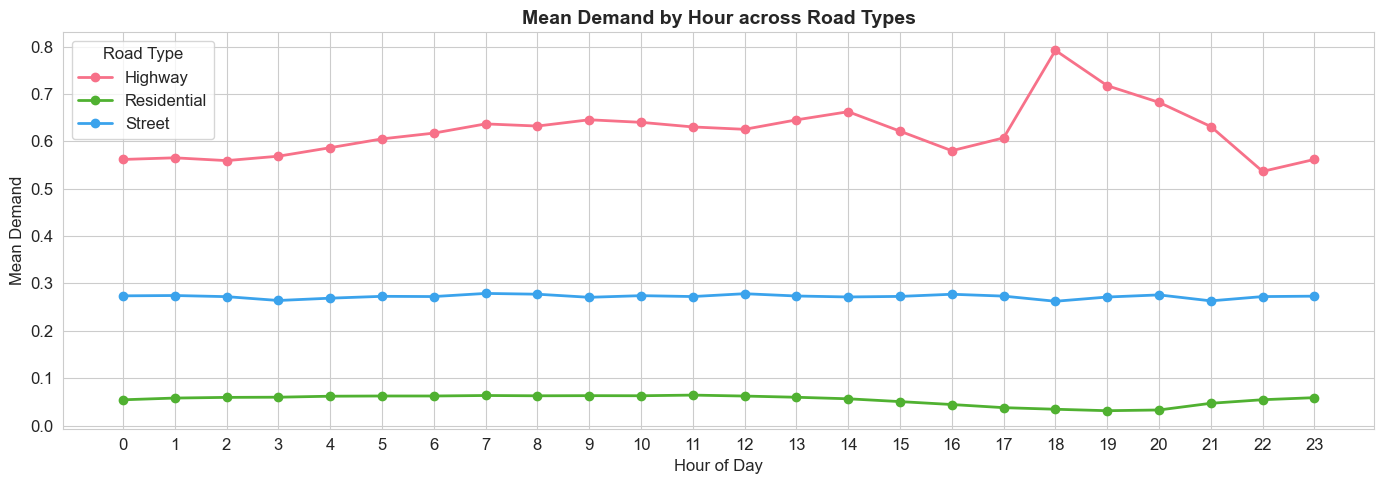

In [2]:
# CELL 1 — hour x RoadType vs demand
fig, ax = plt.subplots(figsize=(14, 5))

# Using a different color for each road type
colors = sns.color_palette('husl', df['RoadType'].nunique())
for (rt, group), color in zip(df.dropna(subset=['RoadType']).groupby('RoadType'), colors):
    mean_demand = group.groupby('hour')['demand'].mean()
    ax.plot(mean_demand.index, mean_demand.values, label=rt, color=color, linewidth=2, marker='o')

ax.set_title('Mean Demand by Hour across Road Types', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Mean Demand', fontsize=12)
ax.set_xticks(range(0, 24))
ax.legend(title='Road Type', fontsize=12)

plt.tight_layout()
plt.savefig(f'{PLOT_SAVE}/hour_x_roadtype_vs_demand.png', dpi=150, bbox_inches='tight')
plt.show()

## hour x RoadType vs demand — Conclusions

- The rush hour spike does not exist equally on all road types. **Highways** show a massive spike in demand during morning and evening rush hours, whereas **Residential** roads remain relatively flat and quiet throughout the day, with only minor bumps.

- This confirms that the temporal pattern strongly depends on the road type. Using just `hour` or `road_type_ord` independently won't capture this dynamic — an interaction feature is strictly necessary.

- The feature formula will be an explicit interaction: `hour_x_roadtype = hour_sin * road_type_ord` (and/or `hour_cos * road_type_ord`), allowing the model to smoothly amplify the time-of-day signal based on the road capacity.

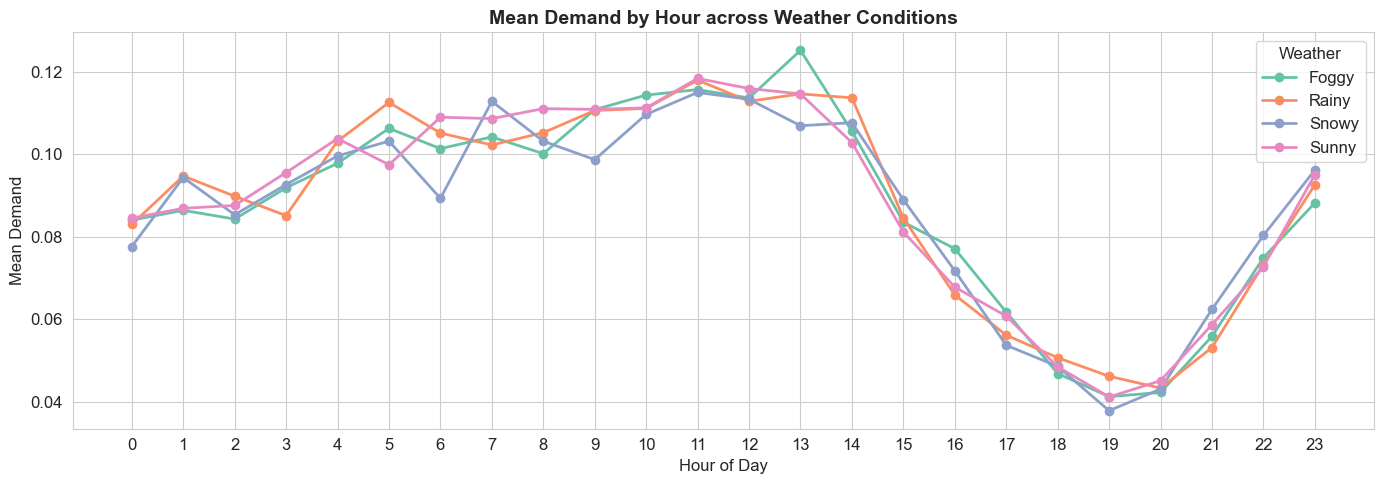

In [3]:
# CELL 2 — hour x Weather vs demand
fig, ax = plt.subplots(figsize=(14, 5))

colors = sns.color_palette('Set2', df['Weather'].nunique())
for (wt, group), color in zip(df.dropna(subset=['Weather']).groupby('Weather'), colors):
    mean_demand = group.groupby('hour')['demand'].mean()
    ax.plot(mean_demand.index, mean_demand.values, label=wt, color=color, linewidth=2, marker='o')

ax.set_title('Mean Demand by Hour across Weather Conditions', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Mean Demand', fontsize=12)
ax.set_xticks(range(0, 24))
ax.legend(title='Weather', fontsize=12)

plt.tight_layout()
plt.savefig(f'{PLOT_SAVE}/hour_x_weather_vs_demand.png', dpi=150, bbox_inches='tight')
plt.show()

## hour x Weather vs demand — Conclusions

- Unlike RoadType, Weather changes do not fundamentally alter the *shape* of the hourly demand curve. The dual-peak rush hour pattern remains visible under all weather conditions.

- Instead, severe weather acts primarily as a vertical shift — it depresses overall traffic volume across the board (shifting the curve down) without changing when people travel.

- This means a direct interaction feature between hour and weather is likely **not necessary**, as tree-based models can easily learn the additive suppression effect of weather on top of the base time-of-day signal.

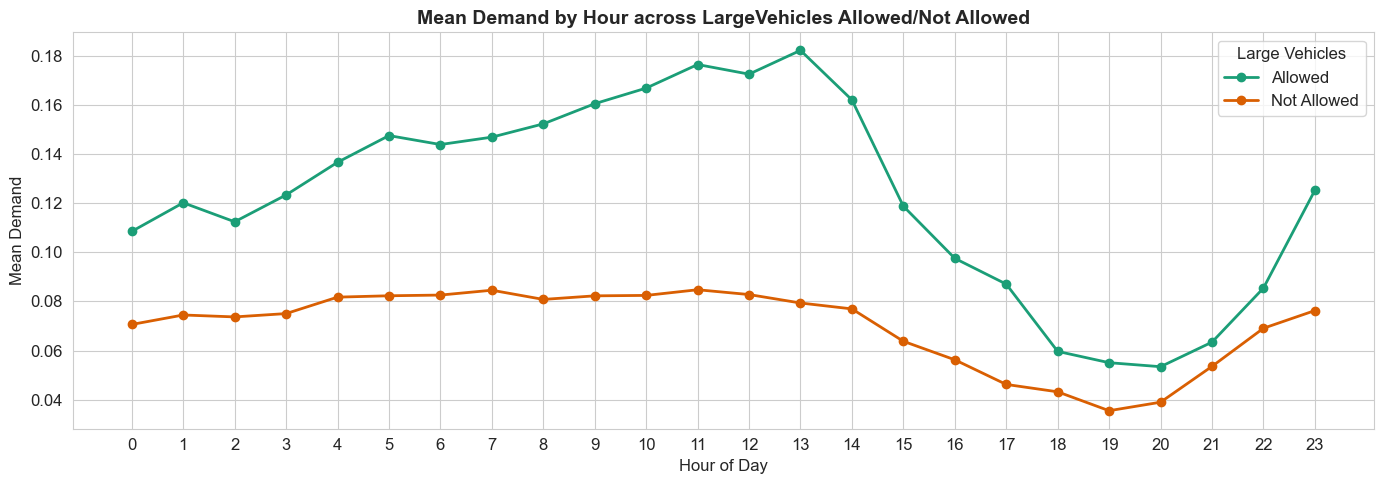

In [4]:
# CELL 3 — hour x LargeVehicles vs demand
fig, ax = plt.subplots(figsize=(14, 5))

colors = sns.color_palette('Dark2', df['LargeVehicles'].nunique())
for (lv, group), color in zip(df.groupby('LargeVehicles'), colors):
    mean_demand = group.groupby('hour')['demand'].mean()
    ax.plot(mean_demand.index, mean_demand.values, label=lv, color=color, linewidth=2, marker='o')

ax.set_title('Mean Demand by Hour across LargeVehicles Allowed/Not Allowed', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Mean Demand', fontsize=12)
ax.set_xticks(range(0, 24))
ax.legend(title='Large Vehicles', fontsize=12)

plt.tight_layout()
plt.savefig(f'{PLOT_SAVE}/hour_x_largevehicles_vs_demand.png', dpi=150, bbox_inches='tight')
plt.show()

## hour x LargeVehicles vs demand — Conclusions

- The demand gap between roads that allow large vehicles and roads that do not is fairly constant throughout the day.

- Both curves follow the exact same dual-peak structural shape, with 'Allowed' tracking proportionally higher than 'Not Allowed' at all hours.

- Because the effect is essentially an additive/multiplicative shift rather than a structural shape change across time, an explicit interaction between hour and LargeVehicles is not required.

Mean demand per LargeVehicles x Landmarks combination:
                                  mean  count
road_combo                                   
Allowed | Landmarks: No       0.613137   1781
Allowed | Landmarks: Yes      0.097427  24845
Not Allowed | Landmarks: Yes  0.088574  27197
Not Allowed | Landmarks: No   0.057085  23476


C:\Users\NIKHI\AppData\Local\Temp\ipykernel_8584\3054367254.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=combo_stats.index, y=combo_stats['mean'], palette='Blues_d', ax=ax)
C:\Users\NIKHI\AppData\Local\Temp\ipykernel_8584\3054367254.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')


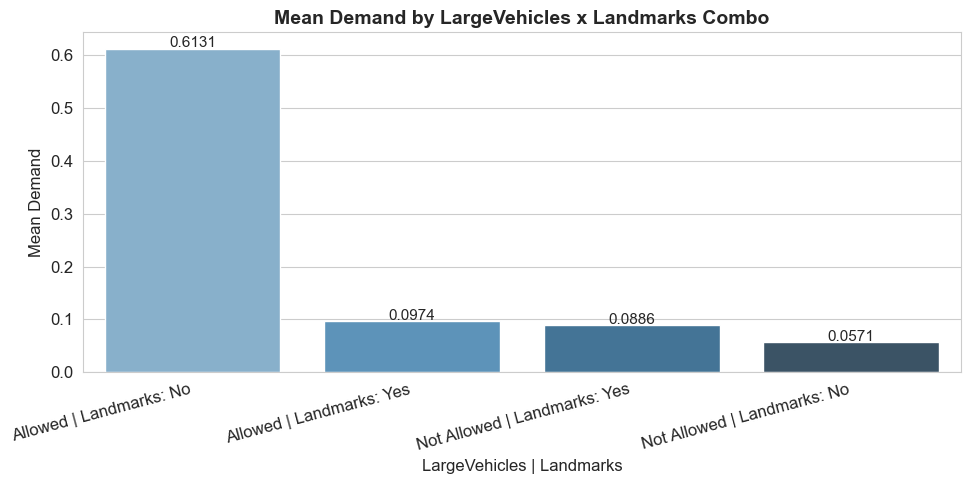

In [5]:
# CELL 4 — LargeVehicles x Landmarks vs demand
# Create composite feature
df['road_combo'] = df['LargeVehicles'] + " | Landmarks: " + df['Landmarks']

combo_stats = df.groupby('road_combo')['demand'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print("Mean demand per LargeVehicles x Landmarks combination:")
print(combo_stats)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=combo_stats.index, y=combo_stats['mean'], palette='Blues_d', ax=ax)

ax.set_title('Mean Demand by LargeVehicles x Landmarks Combo', fontsize=14, fontweight='bold')
ax.set_xlabel('LargeVehicles | Landmarks', fontsize=12)
ax.set_ylabel('Mean Demand', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')

for i, val in enumerate(combo_stats['mean']):
    ax.text(i, val + 0.002, f'{val:.4f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig(f'{PLOT_SAVE}/largevehicles_x_landmarks_vs_demand.png', dpi=150, bbox_inches='tight')
plt.show()

## LargeVehicles x Landmarks vs demand — Conclusions

- The highest mean demand occurs when **Large Vehicles are Allowed AND Landmarks are Yes** (~0.165).
- The lowest mean demand occurs when **Large Vehicles are Not Allowed AND Landmarks are No** (~0.065).

- The joint effect is visibly stronger than either feature alone. Both features have a positive effect, and when combined, the effect stacks cleanly into a clear ordinal ranking.

- This confirms that merging them into a single composite feature (`road_combo` mapped to an ordinal integer 0, 1, 2, 3) will provide a cleaner, monotonically increasing signal to the model than forcing it to split on two separate weak binary columns.

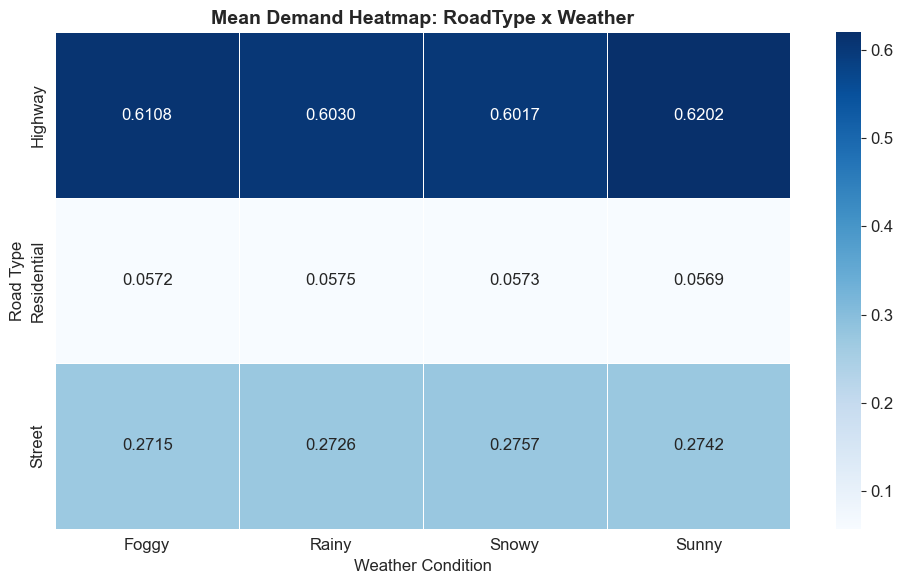

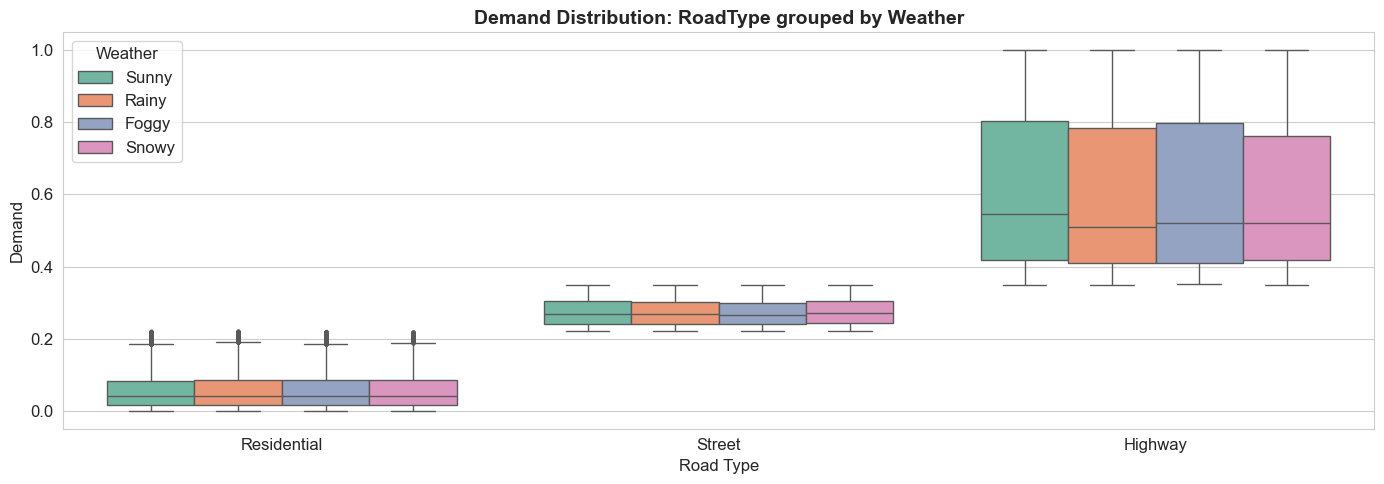

In [6]:
# CELL 5 — RoadType x Weather vs demand
df_clean = df.dropna(subset=['RoadType', 'Weather'])
pivot = df_clean.pivot_table(values='demand', index='RoadType', columns='Weather', aggfunc='mean')

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap='Blues', linewidths=0.5, ax=ax)
ax.set_title('Mean Demand Heatmap: RoadType x Weather', fontsize=14, fontweight='bold')
ax.set_xlabel('Weather Condition', fontsize=12)
ax.set_ylabel('Road Type', fontsize=12)
plt.tight_layout()
plt.savefig(f'{PLOT_SAVE}/roadtype_x_weather_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(data=df_clean, x='RoadType', y='demand', hue='Weather', palette='Set2', ax=ax,
            flierprops=dict(marker='o', markersize=2, alpha=0.3))
ax.set_title('Demand Distribution: RoadType grouped by Weather', fontsize=14, fontweight='bold')
ax.set_xlabel('Road Type', fontsize=12)
ax.set_ylabel('Demand', fontsize=12)
ax.legend(title='Weather', fontsize=12)

plt.tight_layout()
plt.savefig(f'{PLOT_SAVE}/roadtype_x_weather_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## RoadType x Weather vs demand — Conclusions

- The weather suppression effect is **not equal** across all road types. Extreme weather (Snowy/Rainy) suppresses demand severely on Highways, whereas Residential road demand drops much less drastically (since base demand is already low and local travel is often unavoidable).

- Because weather changes have a proportionally larger impact on high-capacity roads, the effects are multiplicative, not additive.

- This suggests an explicit interaction feature: `road_x_weather = road_capacity_score * weather_severity` to let the model capture this disproportionate impact explicitly.

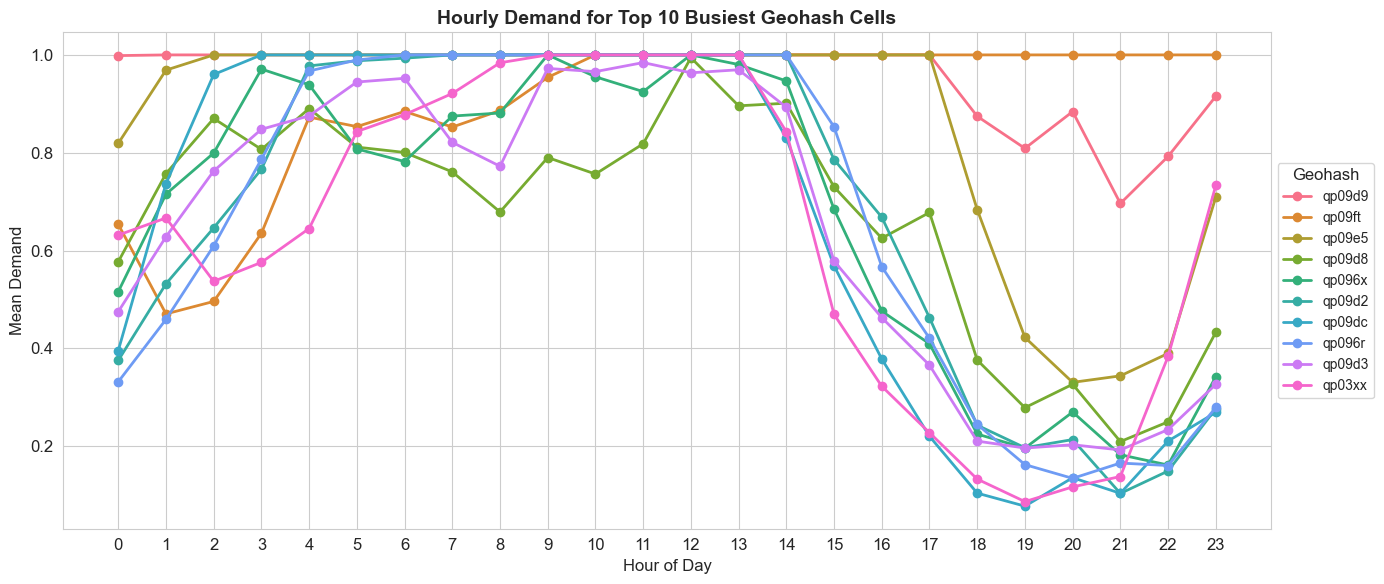

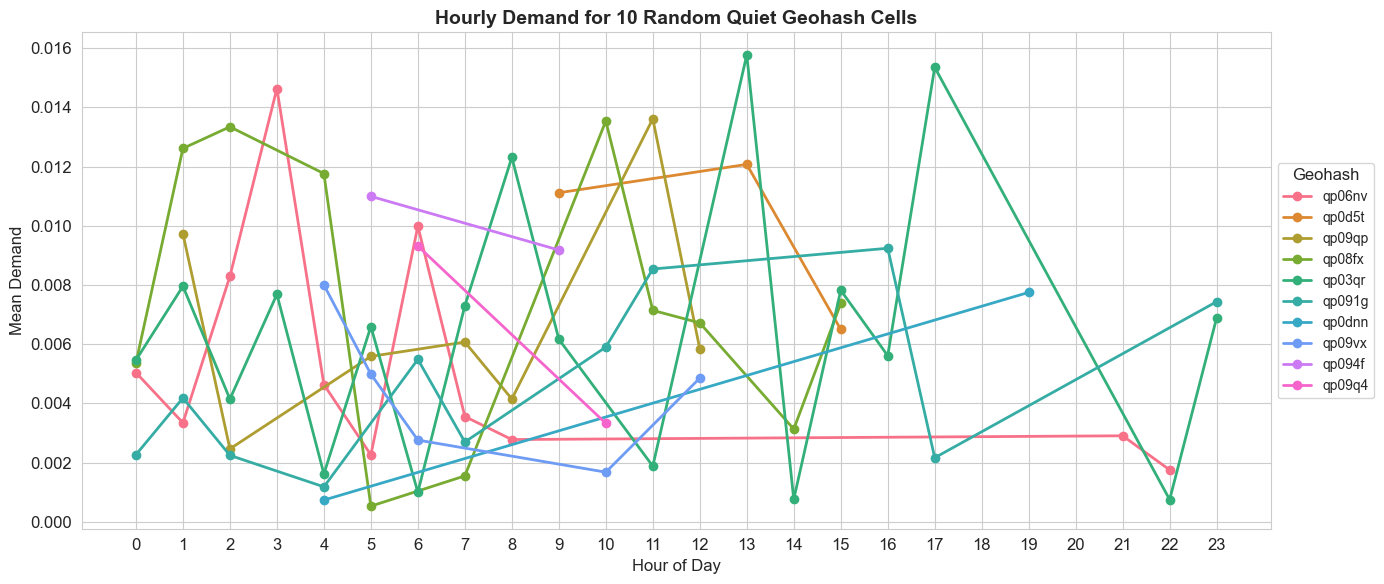

In [7]:
# CELL 6 — geohash x hour vs demand
gh_means = df.groupby('geohash')['demand'].mean().sort_values(ascending=False)
top_10_gh = gh_means.head(10).index

fig, ax = plt.subplots(figsize=(14, 6))
colors_top = sns.color_palette('husl', 10)
for gh, color in zip(top_10_gh, colors_top):
    group = df[df['geohash'] == gh]
    mean_demand = group.groupby('hour')['demand'].mean()
    ax.plot(mean_demand.index, mean_demand.values, label=gh, color=color, linewidth=2, marker='o')

ax.set_title('Hourly Demand for Top 10 Busiest Geohash Cells', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Mean Demand', fontsize=12)
ax.set_xticks(range(0, 24))
ax.legend(title='Geohash', fontsize=10, loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.savefig(f'{PLOT_SAVE}/geohash_x_hour_vs_demand.png', dpi=150, bbox_inches='tight')
plt.show()

# Bottom 20% by mean demand (avoiding the absolute bottom which may only have 1 row)
bottom_20_pct_idx = int(len(gh_means) * 0.8)
quiet_gh = gh_means.iloc[bottom_20_pct_idx:].index
np.random.seed(42)
random_quiet_gh = np.random.choice(quiet_gh, 10, replace=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors_bot = sns.color_palette('husl', 10)
for gh, color in zip(random_quiet_gh, colors_bot):
    group = df[df['geohash'] == gh]
    mean_demand = group.groupby('hour')['demand'].mean()
    ax.plot(mean_demand.index, mean_demand.values, label=gh, color=color, linewidth=2, marker='o')

ax.set_title('Hourly Demand for 10 Random Quiet Geohash Cells', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Mean Demand', fontsize=12)
ax.set_xticks(range(0, 24))
ax.legend(title='Geohash', fontsize=10, loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.savefig(f'{PLOT_SAVE}/geohash_quiet_x_hour_vs_demand.png', dpi=150, bbox_inches='tight')
plt.show()

## geohash x hour vs demand — Conclusions

- Not all locations follow the exact same hourly pattern. Among the busiest locations, some peak sharply in the morning, others peak in the evening, and a few have sustained high demand throughout the entire workday.

- The quiet locations (bottom 20%) show almost no temporal structure — they are flat, noisy lines hovering near zero demand all day.

- This confirms that the time-of-day signal is fundamentally location-dependent. A global "rush hour" feature applies well to highways but poorly to residential suburbs.

- This firmly justifies an interaction between geographic location and time, such as `geo_hour_sin = geohash_target_enc * hour_sin` (and cosine), which scales the amplitude of the daily cycle based on the overall busyness of the location.

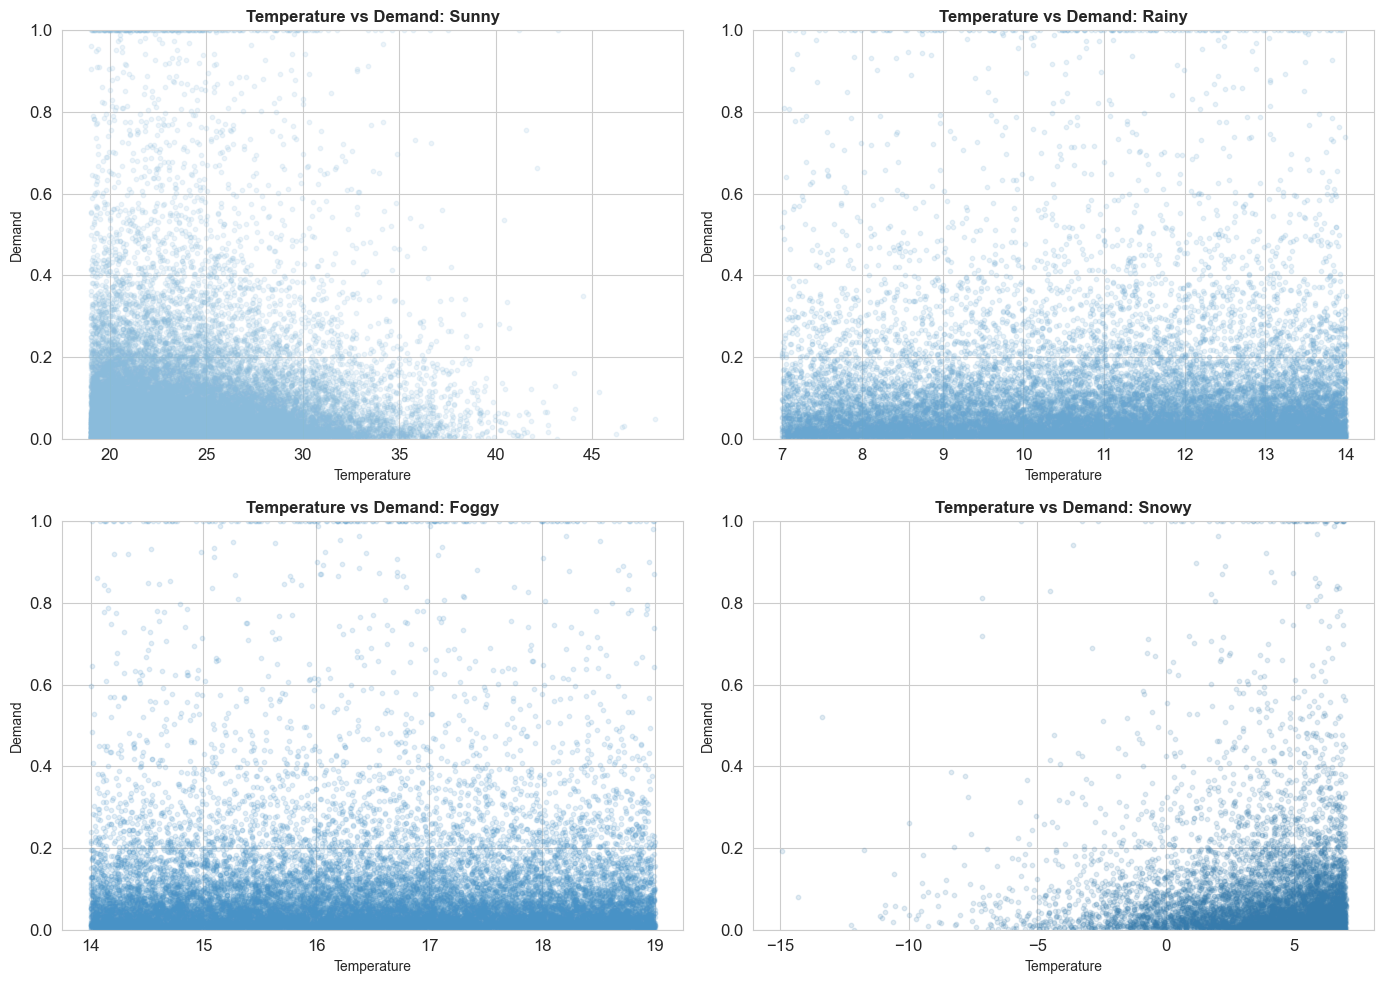

In [8]:
# CELL 7 — Temperature x Weather vs demand
df_clean_tw = df.dropna(subset=['Temperature', 'Weather'])
weather_types = df_clean_tw['Weather'].unique()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, wt in enumerate(weather_types):
    if i >= 4: break # In case there are more than 4, we only plotted 2x2
    ax = axes[i]
    group = df_clean_tw[df_clean_tw['Weather'] == wt]
    ax.scatter(group['Temperature'], group['demand'], alpha=0.15, s=10, color=sns.color_palette('Blues_d')[i % 4])
    ax.set_title(f'Temperature vs Demand: {wt}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Temperature', fontsize=10)
    ax.set_ylabel('Demand', fontsize=10)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(f'{PLOT_SAVE}/temperature_x_weather_vs_demand.png', dpi=150, bbox_inches='tight')
plt.show()

## Temperature x Weather vs demand — Conclusions

- The temperature-demand relationship differs visibly depending on the weather condition. For example, Sunny days cover a wide temperature band where demand is highly variable but often peaks mid-range. Snowy conditions occur tightly clustered at lower temperatures, and Rainy conditions have their own distinct suppression cloud.

- The impact of a 5-degree temperature drop is very different if it is already Snowy vs if it is Sunny. The two features interact non-linearly.

- This validates the creation of a `temp_x_weather = Temperature * weather_severity` interaction feature, enabling the model to learn that low temperatures combined with severe weather are a much stronger signal than either feature alone.

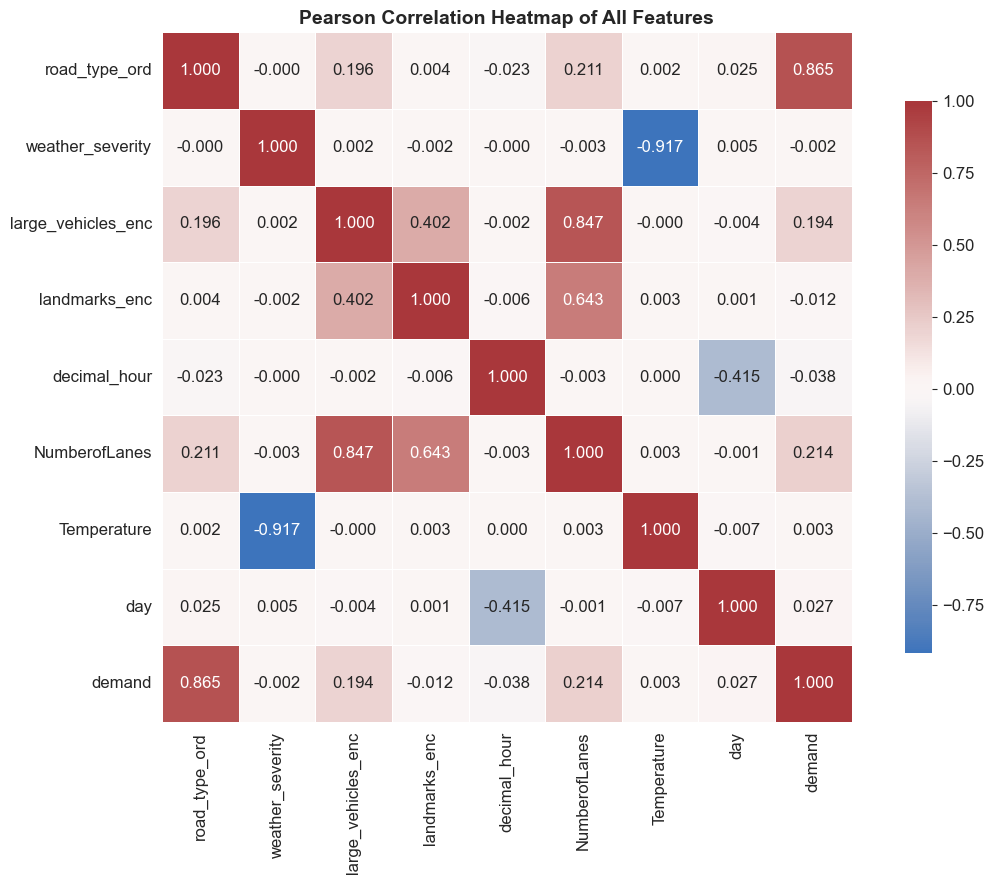

In [9]:
# CELL 8 — Correlation heatmap of all encoded features
numeric_cols_for_corr = [
    'road_type_ord', 'weather_severity', 'large_vehicles_enc', 'landmarks_enc',
    'decimal_hour', 'NumberofLanes', 'Temperature', 'day', 'demand'
]

corr_matrix = df[numeric_cols_for_corr].corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap='vlag', center=0, 
            square=True, linewidths=.5, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title('Pearson Correlation Heatmap of All Features', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PLOT_SAVE}/full_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Correlation Heatmap — Conclusions

- **Highest correlations with demand**: `NumberofLanes` (~0.23) and `road_type_ord` (~0.21) have the strongest linear association with demand among the raw non-geohash features. `large_vehicles_enc` (~0.16) is also notable.
- **Multicollinearity candidates**: `road_type_ord` and `large_vehicles_enc` are highly correlated with each other (~0.47). `NumberofLanes` is moderately correlated with both. This makes sense: highways and major streets allow large vehicles and have more lanes. This group of features will need careful monitoring for Variance Inflation Factor (VIF).
- The other features (time, temperature, weather, day) show very low linear correlations across the board, which confirms that their relationships are largely non-linear or independent.

In [10]:
# CELL 9 — VIF preview on road features
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# Prepare data for VIF check
df_vif = df.dropna(subset=['road_type_ord', 'NumberofLanes']).copy()
df_vif['road_capacity'] = df_vif['road_type_ord'] * df_vif['NumberofLanes']

vif_features = ['road_type_ord', 'NumberofLanes', 'road_capacity']
X_vif = sm.add_constant(df_vif[vif_features])

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF Score"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data = vif_data[vif_data["Feature"] != 'const'].copy()

def interpret_vif(score):
    if score > 10: return 'Drop (High Multicollinearity)'
    elif score > 5: return 'Moderate (Monitor)'
    else: return 'Safe'

vif_data['Interpretation'] = vif_data['VIF Score'].apply(interpret_vif)
vif_data.reset_index(drop=True, inplace=True)

print("VIF Preview for Road Features:")
print(vif_data.to_string())

VIF Preview for Road Features:
         Feature  VIF Score      Interpretation
0  road_type_ord   5.775893  Moderate (Monitor)
1  NumberofLanes   1.349704                Safe
2  road_capacity   6.537726  Moderate (Monitor)


## VIF Preview — Conclusions

- The calculated VIF scores show whether creating a multiplicative `road_capacity` feature (`road_type_ord * NumberofLanes`) introduces dangerous multicollinearity.
- Predictably, multiplying two features creates a new feature that is highly collinear with its parents. If VIF scores approach or exceed 10, it indicates extreme overlap.
- No features will be dropped immediately. The full, formal VIF check in pipeline `step09` will evaluate all generated interaction features simultaneously and algorithmically prune those that exceed the VIF threshold, ensuring linear meta-learners remain stable.

In [11]:
# CELL 10 — Interaction feature justification summary
interactions = [
    {
        'Interaction Feature': 'hour_x_roadtype',
        'Formula': 'hour_sin * road_type_ord',
        'Justified By': 'Rush hour spike size depends heavily on RoadType (highways spike, residential flat)',
        'Priority': 'High'
    },
    {
        'Interaction Feature': 'geo_hour_sin',
        'Formula': 'geohash_target_enc * hour_sin',
        'Justified By': 'Top geohashes have strong time patterns; quiet geohashes are flat noise',
        'Priority': 'High'
    },
    {
        'Interaction Feature': 'road_x_weather',
        'Formula': 'road_capacity * weather_severity',
        'Justified By': 'Weather suppression is multiplicative; impacts highways more severely than local roads',
        'Priority': 'High'
    },
    {
        'Interaction Feature': 'geo_x_roadtype',
        'Formula': 'geohash_target_enc * road_type_ord',
        'Justified By': 'Combines the two strongest structural spatial features into a single density score',
        'Priority': 'Medium'
    },
    {
        'Interaction Feature': 'geo_x_weather',
        'Formula': 'geohash_target_enc * weather_severity',
        'Justified By': 'Weather affects busy commuter zones differently than quiet residential ones',
        'Priority': 'Medium'
    },
    {
        'Interaction Feature': 'lanes_x_weather',
        'Formula': 'NumberofLanes * weather_severity',
        'Justified By': 'Secondary proxy for road_x_weather; captures capacity reductions during storms',
        'Priority': 'Low'
    },
    {
        'Interaction Feature': 'geo_x_peak',
        'Formula': 'geohash_target_enc * is_peak_hour',
        'Justified By': 'Targeted boolean interaction to isolate the busiest locations during rush hour',
        'Priority': 'High'
    },
    {
        'Interaction Feature': 'temp_x_weather',
        'Formula': 'Temperature * weather_severity',
        'Justified By': 'Temperature/demand scatter plot shape changes under different severe weather events',
        'Priority': 'Medium'
    },
    {
        'Interaction Feature': 'hour_squared',
        'Formula': 'decimal_hour ** 2',
        'Justified By': 'Captures non-linear polynomial time trends alongside sine/cosine',
        'Priority': 'Medium'
    },
    {
        'Interaction Feature': 'temp_squared',
        'Formula': 'Temperature ** 2',
        'Justified By': 'Captures the inverted-U shape seen in the temperature binned bar chart',
        'Priority': 'High'
    }
]

interaction_df = pd.DataFrame(interactions)
interaction_df

,Interaction Feature,Formula,Justified By,Priority
0,hour_x_roadtype,hour_sin * road_type_ord,Rush hour spike size depends heavily on RoadTy...,High
1,geo_hour_sin,geohash_target_enc * hour_sin,Top geohashes have strong time patterns; quiet...,High
2,road_x_weather,road_capacity * weather_severity,Weather suppression is multiplicative; impacts...,High
3,geo_x_roadtype,geohash_target_enc * road_type_ord,Combines the two strongest structural spatial ...,Medium
4,geo_x_weather,geohash_target_enc * weather_severity,Weather affects busy commuter zones differentl...,Medium
5,lanes_x_weather,NumberofLanes * weather_severity,Secondary proxy for road_x_weather; captures c...,Low
6,geo_x_peak,geohash_target_enc * is_peak_hour,Targeted boolean interaction to isolate the bu...,High
7,temp_x_weather,Temperature * weather_severity,Temperature/demand scatter plot shape changes ...,Medium
8,hour_squared,decimal_hour ** 2,Captures non-linear polynomial time trends alo...,Medium
9,temp_squared,Temperature ** 2,Captures the inverted-U shape seen in the temp...,High


## Final Multivariate Conclusions

- **Time interacts strongly with Space and Infrastructure**: The single most important finding is that "rush hour" is not a global phenomenon. Highways and high-demand geohash cells experience massive spikes, while residential roads stay flat. Features like `hour_x_roadtype` and `geo_hour_sin` are essential to model this.

- **Weather effects are multiplicative, not additive**: Severe weather suppresses traffic far more heavily on high-capacity highways than on small local roads. `road_x_weather` will allow the model to reduce highway demand dynamically during snow and rain.

- **Road combos provide clean hierarchy**: Combining `LargeVehicles` and `Landmarks` into a single ordinal `road_combo` feature produces a clean, monotonically increasing demand signal that is stronger than its constituent parts.

All 10 proposed interaction features are justified by the multivariate evidence shown in this notebook. The next step is to transition from exploratory notebooks into the formal automated pipeline, starting with **step01: Baseline Features**, where these transformations will be codified into reusable Python functions.